In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [3]:
print(data.target_names)

['malignant' 'benign']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [6]:
y_pred = model.predict(X_test_scaled)

In [7]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [8]:
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:10])

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]
 [1.00000000e+00 9.48087773e-11]
 [9.99999998e-01 1.53672648e-09]
 [9.65096937e-01 3.49030633e-02]
 [3.79342140e-01 6.20657860e-01]
 [7.59402734e-04 9.99240597e-01]]


In [9]:
threshold = 0.7

y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

In [10]:
threshold = 0.3

y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1:", f1_score(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

Accuracy: 0.9824561403508771
Precision: 0.9726027397260274
Recall: 1.0
F1: 0.9861111111111112
[[41  2]
 [ 0 71]]


In [11]:
print(y_prob[:, 1])

[8.86409750e-01 9.00936206e-06 3.07909541e-03 9.99489866e-01
 9.99939361e-01 9.48087773e-11 1.53672648e-09 3.49030633e-02
 6.20657860e-01 9.99240597e-01 9.50128217e-01 1.24071210e-02
 9.93926181e-01 1.43930883e-01 9.98378244e-01 7.40182295e-04
 9.98147541e-01 9.99988834e-01 9.99999182e-01 1.11701472e-06
 9.15836610e-01 9.90252217e-01 4.33732393e-09 9.99921081e-01
 9.98861257e-01 9.99415413e-01 9.98925555e-01 9.94024817e-01
 9.97146883e-01 8.18296669e-06 9.99482590e-01 9.99851240e-01
 9.97839056e-01 9.94505862e-01 9.99859294e-01 9.97576657e-01
 5.75840151e-02 9.97101296e-01 8.87859084e-05 9.51863624e-01
 9.99928757e-01 4.06608387e-04 9.97533594e-01 9.99036115e-01
 9.80010795e-01 9.28445266e-01 9.99601428e-01 9.99509374e-01
 9.69530199e-01 9.99385984e-01 1.20346382e-04 5.31315374e-08
 6.91788480e-01 9.86770623e-01 9.99972637e-01 9.90454756e-01
 9.99887121e-01 7.32867884e-12 1.64426910e-01 9.99860760e-01
 9.94986396e-01 4.49298134e-07 1.41043187e-09 9.68893953e-01
 9.99170906e-01 8.702007

In [12]:
for threshold in [0.3, 0.5, 0.7]:

    y_pred_custom = (y_prob[:, 1] >= threshold).astype(int)

    print("\nThreshold:", threshold)
    print("Accuracy:", accuracy_score(y_test, y_pred_custom))
    print("Precision:", precision_score(y_test, y_pred_custom))
    print("Recall:", recall_score(y_test, y_pred_custom))
    print("F1:", f1_score(y_test, y_pred_custom))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_custom))


Threshold: 0.3
Accuracy: 0.9824561403508771
Precision: 0.9726027397260274
Recall: 1.0
F1: 0.9861111111111112
Confusion Matrix:
[[41  2]
 [ 0 71]]

Threshold: 0.5
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791
Confusion Matrix:
[[41  2]
 [ 1 70]]

Threshold: 0.7
Accuracy: 0.956140350877193
Precision: 0.9852941176470589
Recall: 0.9436619718309859
F1: 0.9640287769784173
Confusion Matrix:
[[42  1]
 [ 4 67]]


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score

In [14]:
auc = roc_auc_score(y_test, y_prob[:, 1])

print("AUC:", auc)

AUC: 0.99737962659679


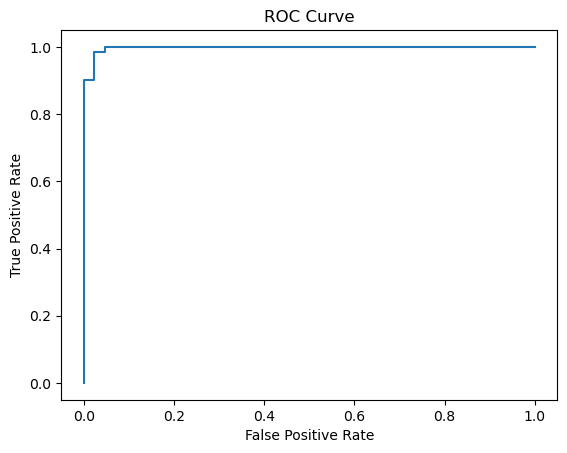

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [16]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob[:, 1]
)

print("Precision:", precision[:10])
print("Recall:", recall[:10])

Precision: [0.62280702 0.62831858 0.63392857 0.63963964 0.64545455 0.65137615
 0.65740741 0.6635514  0.66981132 0.67619048]
Recall: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


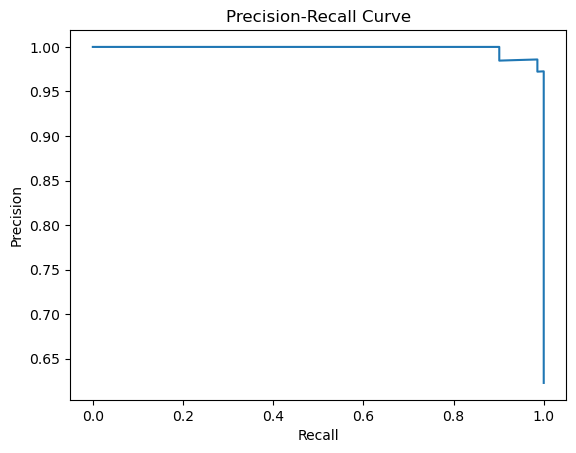

In [17]:
import matplotlib.pyplot as plt

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [18]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob[:, 1])

print("PR-AUC:", pr_auc)

PR-AUC: 0.9983796759737475
